# 1. Criando a Base de Dados

Esta base precisa atender ao MVP e também ser útil para EDA, treinamento supervisionado e geração de recomendações, então ela deve conter pelo menos as variáveis de entrada do endpoint e algumas variáveis auxiliares que expliquem o consumo de forma causal, não aleatória. Em vez de gerar o `consumo_kwh` como número solto, ele foi construído a partir de fatores observáveis, para que a base seja coerente e o modelo aprenda relações realistas.

## 1.2. Variáveis Utilizadas

Variável | Descrição
-- | --
`id_unidade` | Identificador único da residência/estabelecimento.
`tipo_imovel` | Campo exigido no MVP, por exemplo Casa, Apartamento, Pequeno_Comercio
`quantidade_moradores` | Ajuda a explicar maior uso residencial.
`quantidade_equipamentos` | Campo exigido no MVP e forte determinante do consumo
`horas_alto_consumo` | Campo exigido no MVP; representa duração diária média de uso intenso
`uso_horario_pico` | Campo booleano exigido no MVP
`dias_ocupacao_mes` | Diferencia consumo regular de uso esporádico.
`indice_climatizacao` | Proxy para ventilador/ar-condicionado.
`indice_eficiencia_equipamentos` | Variável latente entre 0 e 1; quanto maior, melhor eficiência.

## 1.2. Lógica Utilizada

A função constrói o perfil de cada cliente iterativamente, baseada em comportamentos reais:

- **Distribuição de Imóveis:** Define o tipo de imóvel com probabilidades fixas:
Tipo de Imóvel | Probabilidade
-- | --
Casa | 50%
Apartamento | 30%
Pequeno Comércio | 20%

- **Variáveis Baseadas no Tipo:** Utiliza distribuições estatísticas (Normal e Beta), limitadas pela função `np.clip` para evitar valores irreais. Por exemplo, a lógica garante que casas tendem a ter mais moradores e equipamentos do que apartamentos, e que comércios possuem rotinas de ocupação distintas.

- **Cálculo do Consumo:** O consumo não é puramente aleatório. Ele é uma combinação linear de vários fatores, modelada da seguinte forma:

$$Consumo = \left( B + E + U + Cl + P + M + D \right) \times \left( 1 - 0.28 \cdot I_{eficiencia} \right) + \epsilon$$

>Onde as variáveis representam parcelas de consumo atreladas à **B**ase do imóvel, **E**quipamentos, tempo de **U**so, **Cl**imatização, horário de **P**ico, **M**oradores e fator de **D**esperdício. A soma é multiplicada por um redutor (baseado na eficiência dos equipamentos) e recebe a adição de um ruído estatístico ($\epsilon$) para simular imprevisibilidade.

- **Cálculo do Score de Eficiência:** Classifica o quão bem a unidade consome energia.
$$Score = 100 - 0.09 \cdot Consumo - 10 \cdot Pico - 18 \cdot D + 22 \cdot I_{eficiencia}$$

- **`categoria`:** Utiliza a função `pd.qcut` para dividir o Score de Eficiência em três faixas relativas à própria base de dados: os **20% piores** (Ineficiente), os **50% centrais** (Moderado) e os **30% melhores** (Eficiente).

- **Sistema de Recomendações:** Uma rotina personalizada analisa o perfil gerado para a unidade (ex: se usa energia no horário de pico ou tem índice de desperdício alto) e gera automaticamente até 3 recomendações práticas de economia.

In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

def gerar_base_sintetica_consumo(n=3000, tarifa_kwh=0.75):
    ids = np.arange(1, n + 1)

    tipos = np.random.choice(
        ["Casa", "Apartamento", "Pequeno_Comercio"],
        size=n,
        p=[0.5, 0.3, 0.2]
    )

    quantidade_moradores = []
    quantidade_equipamentos = []
    dias_ocupacao_mes = []
    horas_alto_consumo = []
    indice_climatizacao = []
    indice_eficiencia = []
    fator_desperdicio = []
    uso_horario_pico = []

    for tipo in tipos:
        if tipo == "Casa":
            moradores = np.clip(np.random.normal(3.5, 1.2), 1, 7)
            equipamentos = np.clip(np.random.normal(11, 3), 4, 22)
            dias = np.clip(np.random.normal(29, 2), 20, 31)
            horas = np.clip(np.random.normal(6.5, 1.8), 1, 12)
            climatizacao = np.clip(np.random.beta(2.5, 2.0), 0, 1)
        elif tipo == "Apartamento":
            moradores = np.clip(np.random.normal(2.5, 1.0), 1, 6)
            equipamentos = np.clip(np.random.normal(9, 2.5), 3, 18)
            dias = np.clip(np.random.normal(28.5, 2.5), 18, 31)
            horas = np.clip(np.random.normal(5.5, 1.5), 1, 11)
            climatizacao = np.clip(np.random.beta(2.0, 2.5), 0, 1)
        else:
            moradores = 0
            equipamentos = np.clip(np.random.normal(14, 4), 5, 28)
            dias = np.clip(np.random.normal(26, 4), 15, 31)
            horas = np.clip(np.random.normal(8.0, 2.0), 2, 14)
            climatizacao = np.clip(np.random.beta(2.2, 2.2), 0, 1)

        eficiencia = np.clip(np.random.beta(2.8, 2.2), 0, 1)
        desperdicio = np.clip(np.random.beta(2.2, 3.0), 0, 1)

        prob_pico = 0.25 + 0.35 * desperdicio + 0.15 * (horas / 12)
        pico = np.random.rand() < min(max(prob_pico, 0), 0.95)

        quantidade_moradores.append(round(moradores))
        quantidade_equipamentos.append(round(equipamentos))
        dias_ocupacao_mes.append(round(dias))
        horas_alto_consumo.append(round(horas, 1))
        indice_climatizacao.append(round(climatizacao, 3))
        indice_eficiencia.append(round(eficiencia, 3))
        fator_desperdicio.append(round(desperdicio, 3))
        uso_horario_pico.append(bool(pico))

    df = pd.DataFrame({
        "id_unidade": ids,
        "tipo_imovel": tipos,
        "quantidade_moradores": quantidade_moradores,
        "quantidade_equipamentos": quantidade_equipamentos,
        "dias_ocupacao_mes": dias_ocupacao_mes,
        "horas_alto_consumo": horas_alto_consumo,
        "indice_climatizacao": indice_climatizacao,
        "indice_eficiencia_equipamentos": indice_eficiencia,
        "fator_desperdicio": fator_desperdicio,
        "uso_horario_pico": uso_horario_pico
    })

    intercepto_tipo = {
        "Casa": 95,
        "Apartamento": 75,
        "Pequeno_Comercio": 130
    }

    fator_tipo_equip = {
        "Casa": 7.5,
        "Apartamento": 6.5,
        "Pequeno_Comercio": 9.0
    }

    fator_tipo_uso = {
        "Casa": 11.5,
        "Apartamento": 10.0,
        "Pequeno_Comercio": 13.5
    }

    consumo_base = []
    score_eficiencia = []
    consumo_total = []

    for _, row in df.iterrows():
        base = intercepto_tipo[row["tipo_imovel"]]

        comp_equip = row["quantidade_equipamentos"] * fator_tipo_equip[row["tipo_imovel"]]
        comp_uso = row["horas_alto_consumo"] * fator_tipo_uso[row["tipo_imovel"]] * (row["dias_ocupacao_mes"] / 30)
        comp_clima = 90 * row["indice_climatizacao"]
        comp_pico = 28 if row["uso_horario_pico"] else 0

        if row["tipo_imovel"] != "Pequeno_Comercio":
            comp_moradores = row["quantidade_moradores"] * 12
        else:
            comp_moradores = 0

        redutor_eficiencia = 1 - (0.28 * row["indice_eficiencia_equipamentos"])
        comp_desperdicio = 85 * row["fator_desperdicio"]

        ruido = np.random.normal(0, 12)

        consumo = (
            base +
            comp_equip +
            comp_uso +
            comp_clima +
            comp_pico +
            comp_moradores +
            comp_desperdicio
        ) * redutor_eficiencia + ruido

        consumo = max(60, consumo)

        # Score alto = mais eficiente
        score = (
            100
            - 0.09 * consumo
            - 10 * int(row["uso_horario_pico"])
            - 18 * row["fator_desperdicio"]
            + 22 * row["indice_eficiencia_equipamentos"]
        )

        consumo_base.append(round(base + comp_equip + comp_moradores, 2))
        consumo_total.append(round(consumo, 2))
        score_eficiencia.append(round(score, 2))

    df["consumo_base_kwh"] = consumo_base
    df["consumo_kwh"] = consumo_total
    df["score_eficiencia"] = score_eficiencia
    df["custo_estimado_mensal"] = (df["consumo_kwh"] * tarifa_kwh).round(2)

    df["categoria"] = pd.qcut(
    df["score_eficiencia"],
    q=[0, 0.20, 0.70, 1.0],   # Os 20% mais baixos, os 50% centrais, e os 30% mais altos
    labels=["Ineficiente", "Moderado", "Eficiente"]
    )


    def gerar_recomendacoes(row):
        recomendacoes = []

        if row["uso_horario_pico"]:
            recomendacoes.append("Reduzir o uso de equipamentos durante horários de pico")

        if row["fator_desperdicio"] >= 0.55:
            recomendacoes.append("Revisar hábitos de consumo para reduzir desperdícios energéticos")

        if row["indice_eficiencia_equipamentos"] <= 0.45:
            recomendacoes.append("Avaliar substituição de aparelhos por modelos mais eficientes")

        if row["horas_alto_consumo"] >= 8:
            recomendacoes.append("Distribuir atividades de maior consumo ao longo do dia")

        if row["indice_climatizacao"] >= 0.65:
            recomendacoes.append("Otimizar o uso de climatização e melhorar ventilação dos ambientes")

        if row["quantidade_equipamentos"] >= 14:
            recomendacoes.append("Mapear equipamentos de maior consumo e priorizar uso consciente")

        if len(recomendacoes) == 0:
            recomendacoes.append("Manter os bons hábitos atuais e acompanhar indicadores de consumo")

        while len(recomendacoes) < 3:
            recomendacoes.append("Monitorar o consumo mensal para identificar variações e oportunidades de economia")

        return recomendacoes[:3]

    recs = df.apply(gerar_recomendacoes, axis=1)
    df["recomendacao_1"] = recs.apply(lambda x: x[0])
    df["recomendacao_2"] = recs.apply(lambda x: x[1])
    df["recomendacao_3"] = recs.apply(lambda x: x[2])

    return df


# Geração da base
df = gerar_base_sintetica_consumo(n=3000, tarifa_kwh=0.75)

# Salvar em CSV
df.to_csv("base_sintetica_consumo_energia.csv", index=False, encoding="utf-8-sig")

# Exibir amostra
print(df.head())

# Distribuição das classes
print(df["categoria"].value_counts())

# Estatísticas principais
print(df[["consumo_kwh", "custo_estimado_mensal", "horas_alto_consumo", "quantidade_equipamentos"]].describe())

   id_unidade       tipo_imovel  quantidade_moradores  \
0           1              Casa                     5   
1           2  Pequeno_Comercio                     0   
2           3       Apartamento                     1   
3           4       Apartamento                     1   
4           5              Casa                     4   

   quantidade_equipamentos  dias_ocupacao_mes  horas_alto_consumo  \
0                       13                 30                 4.0   
1                       11                 25                 6.6   
2                        7                 26                 6.0   
3                        5                 28                 6.9   
4                       13                 27                 8.0   

   indice_climatizacao  indice_eficiencia_equipamentos  fator_desperdicio  \
0                0.689                           0.483              0.437   
1                0.828                           0.703              0.554   
2          

Separamos variáveis explicativas, derivadas e alvo visando melhora a qualidade metodológica porque evita vazamento de informação: o modelo aprende a prever categoria a partir de sinais observáveis, enquanto `custo_estimado_mensal` é uma consequência direta do consumo, não uma entrada do modelo.

A segunda escolha foi usar distribuições diferentes por `tipo_imovel`. Já que o projeto pede residêcia ou pequeno estabelecimento, misturar ambos com a mesma distribuição criaria uma base incoerente. Um pequeno comércio tende a operar mais horas, ter mais equipamentos e maior carga estrutural, então o intercepto e os coeficientes precisam ser maiores.

A terceira escolha foi introduzir `indice_eficiencia_equipamento`s e `fator_desperdicio`. Já que precisamos identificar desperdícios, classificar eficiência e gerar recomendações; sem variáveis latentes desse tipo, a categoria ficaria excessivamente dependente só do consumo bruto. Isso seria péssimo, porque alto consumo nem sempre significa ineficiência; pode significar apenas maior necessidade operacional.

A quarta escolha foi calcular `consumo_kwh` por composição aditiva com redutor multiplicativo de eficiência. Essa arquitetura é boa porque modela dois fenômenos diferentes: primeiro o quanto a unidade “precisa” consumir, depois o quanto ela consome a mais ou a menos dependendo da eficiência. Em termos práticos:

- parte aditiva = necessidade operacional;

- parte multiplicativa = qualidade energética dos aparelhos e hábitos.

A quinta escolha foi criar um `score_eficiencia` contínuo antes da classe final. Isso é melhor do que classificar diretamente com regras duras, porque permite explicar limiares, ajustar fronteiras de classe e até validar depois com histogramas e separabilidade entre grupos. Assim, Eficiente, Moderado e Ineficiente passam a ser faixas de um continuum de eficiência, o que é conceitualmente mais consistente.

**Com isso:**

- mais `quantidade_equipamentos` tende a elevar `consumo_kwh`;

- mais `horas_alto_consumo` tende a elevar `consumo_kw`;

- presença de `uso_horario_pico` tende a piorar o perfil;

- maior `indice_eficiencia_equipamentos` tende a reduzir consumo;

- maior `fator_desperdicio` tende a aumentar consumo e piorar a classe;

- `custo_estimado_mensal` é exatamente proporcional ao consumo, usando a tarifa sugerida de R$ 0,75/kWh.

# 2. EDA

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   id_unidade                      3000 non-null   int64   
 1   tipo_imovel                     3000 non-null   object  
 2   quantidade_moradores            3000 non-null   int64   
 3   quantidade_equipamentos         3000 non-null   int64   
 4   dias_ocupacao_mes               3000 non-null   int64   
 5   horas_alto_consumo              3000 non-null   float64 
 6   indice_climatizacao             3000 non-null   float64 
 7   indice_eficiencia_equipamentos  3000 non-null   float64 
 8   fator_desperdicio               3000 non-null   float64 
 9   uso_horario_pico                3000 non-null   bool    
 10  consumo_base_kwh                3000 non-null   float64 
 11  consumo_kwh                     3000 non-null   float64 
 12  score_eficiencia    

In [3]:
# Estatísticas das variáveis numéricas principais
cols_numericas = [
    "consumo_kwh",
    "custo_estimado_mensal",
    "quantidade_equipamentos",
    "horas_alto_consumo",
    "quantidade_moradores",
    "dias_ocupacao_mes",
    "indice_climatizacao",
    "indice_eficiencia_equipamentos",
    "fator_desperdicio",
    "consumo_base_kwh",
    "score_eficiencia"
]

df[cols_numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
consumo_kwh,3000.0,315.709833,62.473492,141.850,270.7725,314.420,358.1775,547.290
custo_estimado_mensal,3000.0,236.782367,46.855106,106.390,203.0750,235.815,268.6350,410.470
quantidade_equipamentos,3000.0,10.955000,3.514697,3.000,8.0000,11.000,13.0000,27.000
horas_alto_consumo,3000.0,6.500867,1.995941,1.000,5.1000,6.400,7.8000,14.000
quantidade_moradores,3000.0,2.505333,1.689257,0.000,1.0000,3.000,4.0000,7.000
dias_ocupacao_mes,3000.0,28.030000,2.668359,15.000,27.0000,28.000,30.0000,31.000
indice_climatizacao,3000.0,0.510375,0.219411,0.014,0.3430,0.514,0.6790,0.989
indice_eficiencia_equipamentos,3000.0,0.564970,0.203325,0.044,0.4100,0.572,0.7250,0.993
fator_desperdicio,3000.0,0.416849,0.194990,0.015,0.2610,0.404,0.5590,0.949
consumo_base_kwh,3000.0,209.836500,42.898509,106.500,176.0000,210.500,238.0000,373.000


In [4]:
df["categoria"].value_counts()

,count
categoria,
Moderado,1500
Eficiente,900
Ineficiente,600


In [5]:
df["tipo_imovel"].value_counts()

,count
tipo_imovel,
Casa,1485
Apartamento,907
Pequeno_Comercio,608


In [6]:
df.groupby("tipo_imovel")["consumo_kwh"].agg(["mean", "median", "min", "max"])

,mean,median,min,max
tipo_imovel,,,,
Apartamento,256.705755,257.240,141.85,379.08
Casa,328.856828,326.620,184.46,508.13
Pequeno_Comercio,371.620049,368.555,245.01,547.29


## 2.1. Análise de Correlação entre Variáveis

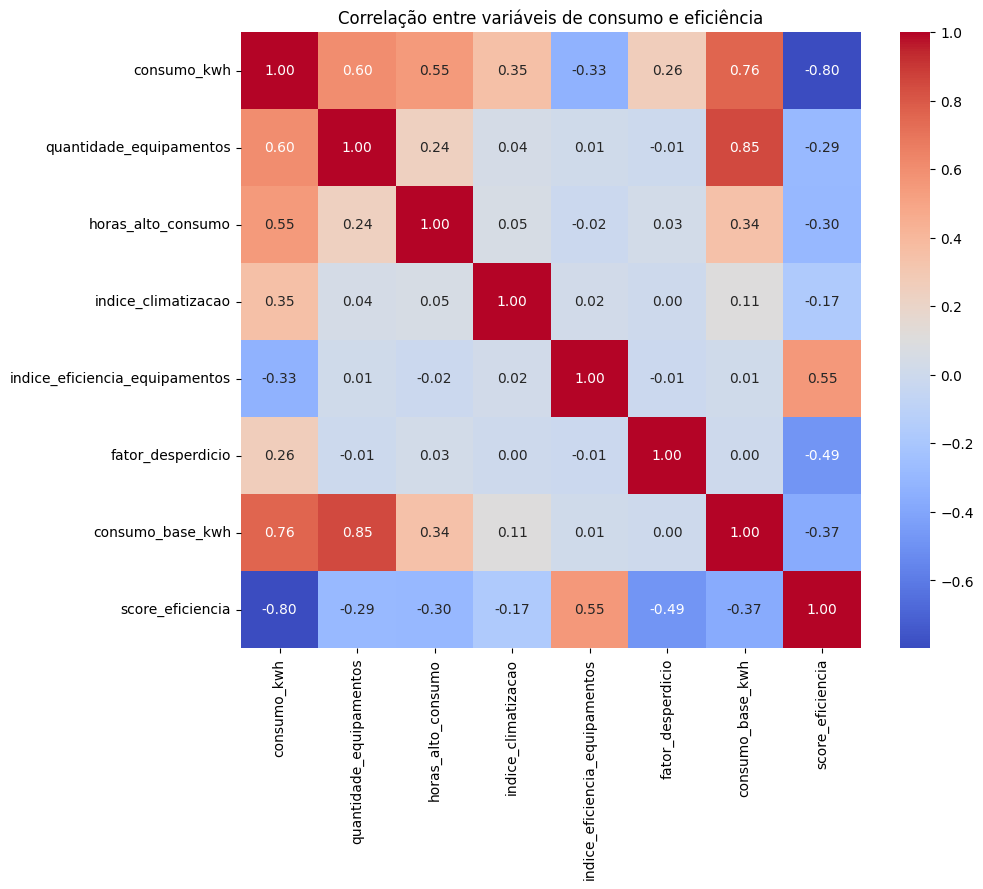

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Matriz de correlação para variáveis de interesse
cols_corr = [
    "consumo_kwh",
    "quantidade_equipamentos",
    "horas_alto_consumo",
    "indice_climatizacao",
    "indice_eficiencia_equipamentos",
    "fator_desperdicio",
    "consumo_base_kwh",
    "score_eficiencia"
]

corr = df[cols_corr].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlação entre variáveis de consumo e eficiência")
plt.show()

- Existe uma forte correlação negativa (-0.80) entre `consumo_kwh` e `score_eficiencia`. Isso comprova que a lógica funcionou: imóveis que consomem muita energia tendem a ter uma nota de eficiência muito menor.

- O `indice_eficiencia_equipamentos` tem uma correlação positiva (0.55) com o `score_eficiencia`, mostrando que bons equipamentos ajudam a elevar a nota do imóvel.

- A variável `consumo_base_kwh` possui uma correlação altíssima (0.85) com a `quantidade_equipamentos`. Dependendo do modelo utilizado, talvez seja necessário remover uma delas.

## 2.2. Distribuição do consumo por categoria


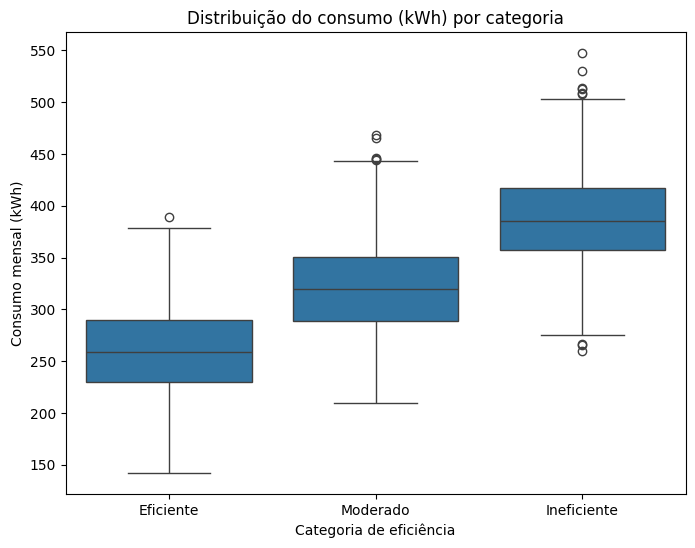

In [8]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="categoria", y="consumo_kwh", order=["Eficiente", "Moderado", "Ineficiente"])
plt.title("Distribuição do consumo (kWh) por categoria")
plt.ylabel("Consumo mensal (kWh)")
plt.xlabel("Categoria de eficiência")
plt.show()

- A mediana sobe drasticamente da categoria "Eficiente" (aprox. 260 kWh) para a "Ineficiente" (aprox. 380 kWh). Isso significa que as classes estão bem separadas e representam de fato perfis de consumo muito diferentes. Os modelos de classificação terão facilidade em capturar essa separação.

- Embora as medianas sejam distintas, as caixas e as hastes se sobrepõem. Isso reflete a realidade: é possível que um imóvel classificado como "Moderado" consuma o mesmo que um "Ineficiente", mas compense isso tendo excelentes equipamentos e pouco desperdício.

- Há outliers. Precisaremos decidir se tratamos esses outliers ou se os mantemos como anomalias naturais do processo.

## 2.3. Relação entre Custo e Categoria

In [9]:
df.groupby("categoria")["custo_estimado_mensal"].agg(["mean", "median", "min", "max"])

/tmp/ipykernel_53792/1044640060.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("categoria")["custo_estimado_mensal"].agg(["mean", "median", "min", "max"])


,mean,median,min,max
categoria,,,,
Ineficiente,290.441417,288.905,194.80,410.47
Moderado,240.214407,239.750,157.45,350.98
Eficiente,195.289600,193.880,106.39,291.67


- Existe uma diferença clara. A conta de luz média de um imóvel "Ineficiente" (aprox. 290) é consideravelmente maior do que a de um imóvel "Eficiente" (aprox. 195). Isso valida a utilidade do Score de Eficiência na vida real.

- A média e a mediana de cada categoria possuem valores extremamente próximos. Isso indica que a distribuição de custos dentro de cada grupo é simétrica, sem a presença de anomalias severas que puxam a média parra cima ou para baixo.

- O custo máximo de um imóvel "Eficiente" (291.67) é superior ao custo mínimo de um imóvel "Ineficiente" (194.80). Isso faz sentido: uma mansão muito eficiente com muitos equipamentos ainda pagará uma conta de luz mais alta do que um apartamento pequeno e ineficiente. Isso reforça que o modelo precisará olhar para o conjunto de variáveis (moradores, equipamentos, etc.), e não apenas para o valor final da conta.

## 2.4. Horário de Pico

In [10]:
pd.crosstab(df["categoria"], df["uso_horario_pico"], normalize="index")

uso_horario_pico,False,True
categoria,,
Ineficiente,0.116667,0.883333
Moderado,0.460000,0.540000
Eficiente,0.896667,0.103333


- 88.3% dos imóveis classificados como "Ineficientes" utilizam energia em horários de pico.

- Quase 90% dos imóveis "Eficientes" não utilizam energia em horários de pico.

- Essa tabela é um forte indício de que a variável `uso_horario_pico` será um dos preditores mais importantes para classificar corretamente a eficiência.

In [11]:
df.groupby("uso_horario_pico")["consumo_kwh"].agg(["mean", "median"])

,mean,median
uso_horario_pico,,
False,300.598979,299.27
True,332.233706,328.98


## 2.5. Perfil de eficiência vs. desperdício e eficiência de equipamentos


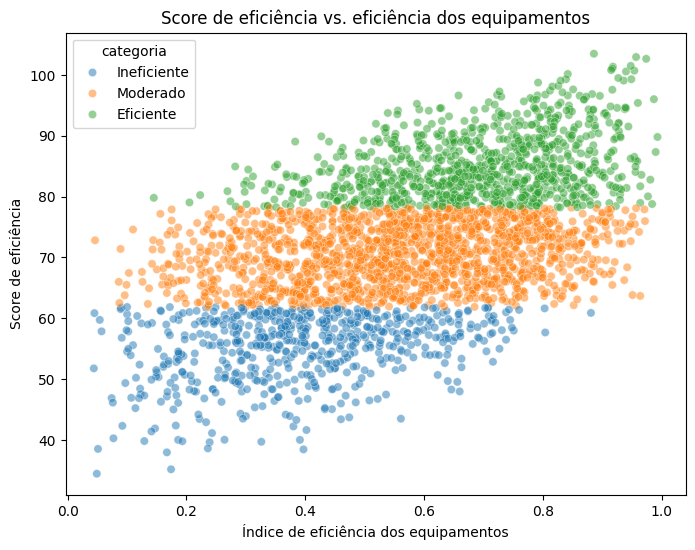

In [12]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="indice_eficiencia_equipamentos", y="score_eficiencia", hue="categoria", alpha=0.5)
plt.title("Score de eficiência vs. eficiência dos equipamentos")
plt.xlabel("Índice de eficiência dos equipamentos")
plt.ylabel("Score de eficiência")
plt.show()

- As cores formam blocos horizontais perfeitos. Isso acontece porque a nossa `categoria` foi criada exatamente a partir do corte (`pd.qcut`) do eixo Y. O gráfico valida que a separação das classes ocorreu sem vazamento de dados.

- Observando a nuvem de pontos como um todo, vemos uma inclinação diagonal ascendente. Isso confirma visualmente a correlação positiva que vimos no Heatmap: quanto melhor o índice dos equipamentos, maior tende a ser o score final.

- Na marca de `0.8` no eixo X há pontos verdes, laranjas e azuis na mesma linha vertical. Isso sufere que ter equipamentos excelentes não é suficiente por si só. Se o imóvel tem bons aparelhos, mas gasta energia no horário de pico e tem alto fator de desperdício, o score dele cai. Isso indica que nenhuma variável sozinha resolve o problema, justificando o uso de algoritmos de Machine Learning para capturar essas combinações.

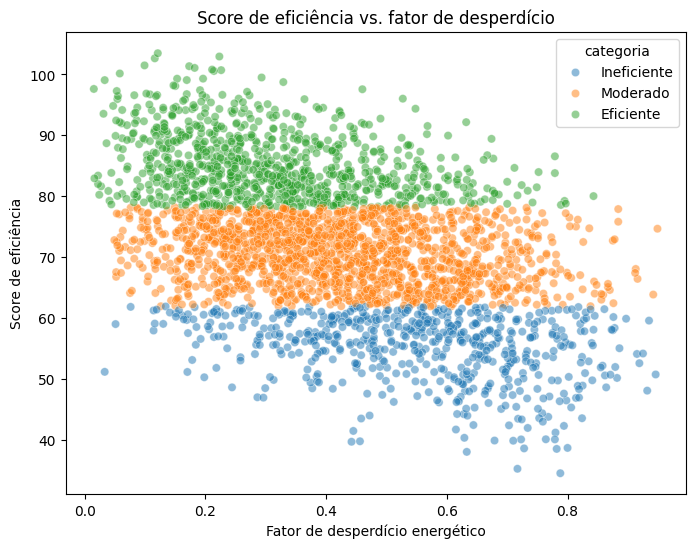

In [13]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="fator_desperdicio", y="score_eficiencia", hue="categoria", alpha=0.5)
plt.title("Score de eficiência vs. fator de desperdício")
plt.xlabel("Fator de desperdício energético")
plt.ylabel("Score de eficiência")
plt.show()

- Diferente do gráfico de equipamentos, a nuvem de pontos aqui apresenta uma clara inclinação para baixo. Isso valida matematicamente que o aumento do desperdício empurra o score do imóvel para baixo. É a confirmação visual da correlação negativa que vimos no Heatmap.

- Na faixa vertical no eixo X em torno de 0.6 a 0.8 ainda existem alguns raros pontos verdes. Isso indica que é possível compensar maus hábitos com o uso de equipamentos eficientes e evitando o horário de pico. Mais uma vez, isso justifica o uso de algoritmos avançados de Machine Learning, pois regras simples (ex: "se desperdício > 0.6, então ineficiente") falhariam nesses casos.

- A densidade de pontos é muito maior do lado esquerdo do gráfico e vai afinando conforme chegamos perto de 1.0. Isso mostra que, de forma geral, a maioria dos perfis gerados tenta manter algum nível de controle energético.

## 2.6. Coesão Custo-Consumo

In [14]:
# Verificar se custo é aproximadamente 0.75 * consumo
df["custo_teorico"] = (df["consumo_kwh"] * 0.75).round(2)
diferenca = (df["custo_estimado_mensal"] - df["custo_teorico"]).abs().max()
diferenca

0.0

- Isso é um indício que não há problemas lógicos nessa base de dados (indíco não é prova).

- Um modelo de otimização financeira constru'do em cima da coluna `custo_estimado_mensal` estará utilizando dados fiéis ao consumo real do imóvel.

# 3. Modelagem e Treinamento

In [15]:
from sklearn.model_selection import train_test_split

features = [
    "consumo_kwh",
    "uso_horario_pico",
    "quantidade_equipamentos",
    "tipo_imovel",
    "horas_alto_consumo",
    "quantidade_moradores",
    "dias_ocupacao_mes",
    "indice_climatizacao",
    "indice_eficiencia_equipamentos",
    "fator_desperdicio",
]

X = df[features]

y = df["categoria"]

- As variáveis `score_eficiencia` e `custo_estimado_mensal` não foram incluídas no `X` pois `categoria` foi criada matematicamente a partir do `score_eficiencia`. Então se passássemos essa variável para o modelo, ele iria decorar a regra e acertar 100%.

## 3.1. Tratamento de tipos

In [16]:
if X["uso_horario_pico"].dtype == bool:
    X["uso_horario_pico"] = X["uso_horario_pico"].astype(int)

/tmp/ipykernel_53792/3569868338.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["uso_horario_pico"] = X["uso_horario_pico"].astype(int)


In [17]:
X["uso_horario_pico"].dtype

dtype('int64')

## 3.2. Divisão Treino, Teste e Validação

In [18]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)

## 3.3 Definição de Colunas Numéricas e Categóricas


In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

numeric_features = [
    "consumo_kwh",
    "quantidade_equipamentos",
    "horas_alto_consumo",
    "quantidade_moradores",
    "dias_ocupacao_mes",
    "indice_climatizacao",
    "indice_eficiencia_equipamentos",
    "fator_desperdicio",
    "uso_horario_pico",
]

categorical_features = ["tipo_imovel"]

## 3.4. Pipeline de Pré-Processamento

In [20]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

## 3.5. Modelos

In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("scaler", StandardScaler(with_mean=False)),
        ("model", LogisticRegression(random_state=42, max_iter=1000))
    ]),
    "KNN": Pipeline([
        ("preprocessor", preprocessor),
        ("scaler", StandardScaler(with_mean=False)),
        ("model", KNeighborsClassifier())
    ]),
    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(random_state=42))
    ]),
    "Decision Tree": Pipeline([
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(random_state=42))
    ]),
    "XGBoost": Pipeline([
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))
    ])
}

- A Regressão Logística e o KNN possuem o passo `scaler` no pipeline, mas as Árvores, o Random Forest e o XGBoost não possuem. Modelos baseados em distância (KNN) ou gradiente linear (Logística) são sensíveis à escala (se o consumo está na casa dos 300 e moradores na casa do 3, o algoritmo acharia erroneamente que o consumo é 100x mais importante). Já os modelos baseados em Árvores funcionam por "cortes lógicos", sendo totalmente imunes à diferença de escalas.

## 3.6. Grade de Parâmetros

In [22]:
param_grids = {
    "Logistic Regression": {
        # 'C' controla a força da regularização
        "model__C": [0.1, 1.0, 10.0],
        "model__class_weight": [None, "balanced"]
    },
    "KNN": {
        # 'n_neighbors' é o número de vizinhos mais próximos
        "model__n_neighbors": [3, 5, 7, 11],
        # weights: se vizinhos mais próximos têm peso maior ou igual aos mais distantes
        "model__weights": ["uniform", "distance"]
    },
    "Random Forest": {
        # Quantidade de árvores e profundidade máxima
        "model__n_estimators": [50, 100, 200],
        "model__max_depth": [None, 10, 20],
        "model__min_samples_split": [2, 5]
    },
    "Decision Tree": {
        # Profundidade da árvore e mínimo de amostras para dividir
        "model__max_depth": [None, 5, 10, 15, 20],
        "model__min_samples_split": [2, 10, 20]
    },
    "XGBoost": {
        # Número de árvores
        "model__n_estimators": [50, 100, 200],
        "model__max_depth": [3, 6, 9],
        "model__learning_rate": [0.01, 0.1, 0.2]
    }
}

- Os valores escolhidos não são aleatórios. Por exemplo, permitir uma árvore sem limite de profundidade (`max_depth: None`) fará com que ela decore a base de treino, mas limitá-la demais (`max_depth: 3`) pode impedi-la de aprender padrões complexos. A grade serve para tentarmos achar o meio-termo.

- O tamanho dessas listas impacta diretamente o tempo de processamento. No Random Forest, por exemplo, temos 3 opções de `n_estimators`, 3 de `max_depth` e 2 de `min_samples_split`. Isso gera 18 combinações diferentes. Se usarmos validação cruzada com 5 vias na próxima etapa, apenas o modelo Random Forest será treinado 90 vezes. É importante ter isso em mente caso decidamos adicionar mais números a essas listas no futuro.

## 3.7. Encoding

In [23]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val = le.transform(y_val)
y_test = le.transform(y_test)

mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"Classes Mapeadas: {mapping}\n")

Classes Mapeadas: {'Eficiente': np.int64(0), 'Ineficiente': np.int64(1), 'Moderado': np.int64(2)}



- O `LabelEncoder` simplesmente atribui os números 0, 1 e 2 seguindo a ordem alfabética das classes ("Eficiente" = 0, "Ineficiente" = 1, "Moderado" = 2). A impressão do dicionário `mapping` na tela é fundamental para podermos "traduzir" as previsões matemáticas do modelo mais a frente.

## 3.8. Treinamento

In [24]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

resultados_otimizados = []
modelos_treinados = {}

for nome, pipeline in models.items():
    print(f"Treinando e otimizando: {nome}...")

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[nome],
        scoring='f1_weighted',
        cv=5,
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)

    melhor_modelo = grid_search.best_estimator_
    modelos_treinados[nome] = melhor_modelo

    y_pred_val = melhor_modelo.predict(X_val)
    f1 = f1_score(y_val, y_pred_val, average='weighted')

    resultados_otimizados.append({
        "Modelo": nome,
        "Melhor Configuração": grid_search.best_params_,
        "F1-Score (Validação)": f1
    })

df_otimizado = pd.DataFrame(resultados_otimizados).sort_values(by="F1-Score (Validação)", ascending=False)
print("\n--- RESULTADOS DA OTIMIZAÇÃO ---")
display(df_otimizado)

Treinando e otimizando: Logistic Regression...
Treinando e otimizando: KNN...
Treinando e otimizando: Random Forest...
Treinando e otimizando: Decision Tree...
Treinando e otimizando: XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:21:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- RESULTADOS DA OTIMIZAÇÃO ---


,Modelo,Melhor Configuração,F1-Score (Validação)
0,Logistic Regression,"{'model__C': 10.0, 'model__class_weight': None}",0.993321
4,XGBoost,"{'model__learning_rate': 0.1, 'model__max_dept...",0.944967
2,Random Forest,"{'model__max_depth': None, 'model__min_samples...",0.913024
3,Decision Tree,"{'model__max_depth': None, 'model__min_samples...",0.876681
1,KNN,"{'model__n_neighbors': 7, 'model__weights': 'd...",0.856456


- O fato de um modelo linear simples ter batido modelos complexos como XGBoost e Random Forest faz todo o sentido já que nós geramos a coluna `score_eficiencia` a partir de uma equação linear perfeita na primeira célula. Como a Regressão Logística é excelente em encontrar relações lineares diretas, ela conseguiu "desvendar" a nossa fórmula matemática com quase 100% de perfeição. Não sei se faria sentido nós tentarmos deixar nossa fómula mais complexa.

- XGBoost e Random Forest tiveram desempenhos espetaculares, mostrando que também conseguiram mapear as regras de penalização de horário de pico e desperdício com muita precisão, configurando-se como opções robustas caso a base fosse preenchida com dados mais realistas (que tendem a ser menos lineares e mais ruidosos).

- KNN ficou em último. O que era esperado por causa da maldição da dimensionalidade.

### 3.8.1 Teste

In [26]:
from sklearn.metrics import classification_report, confusion_matrix

modelo_mais_preciso = modelos_treinados["Logistic Regression"]

y_pred_test = modelo_mais_preciso.predict(X_test)

print("--- Performance com o set de Teste ---")
print(f"F1-Score Final: {f1_score(y_test, y_pred_test, average='weighted'):.4f}\n")

classes_name = le.inverse_transform([0, 1, 2])
print(classification_report(y_test, y_pred_test, target_names=classes_name))

--- Performance com o set de Teste ---
F1-Score Final: 0.9950

              precision    recall  f1-score   support

   Eficiente       0.99      0.99      0.99       180
 Ineficiente       1.00      0.99      1.00       120
    Moderado       0.99      1.00      1.00       300

    accuracy                           0.99       600
   macro avg       1.00      0.99      1.00       600
weighted avg       1.00      0.99      1.00       600



## 3.8.2 Interpretabilidade

In [28]:
nomes_features = modelo_mais_preciso.named_steps['preprocessor'].get_feature_names_out()

pesos = modelo_mais_preciso.named_steps['model'].coef_[0]

df_importancia = pd.DataFrame({
    'Feature': nomes_features,
    'Peso': pesos
}).sort_values(by='Peso', key=abs, ascending=False)

print("--- TOP 5 FATORES QUE MAIS IMPACTAM A DECISÃO DO MODELO ---")
display(df_importancia.head(5))

--- TOP 5 FATORES QUE MAIS IMPACTAM A DECISÃO DO MODELO ---


,Feature,Peso
0,num__consumo_kwh,-11.162920
8,num__uso_horario_pico,-10.707442
6,num__indice_eficiencia_equipamentos,9.557272
7,num__fator_desperdicio,-7.473845
11,cat__tipo_imovel_Pequeno_Comercio,-0.726376


- Os Grandes Inimigos da Eficiência (Pesos Negativos):
   - `num__consumo_kwh` e `num__uso_horario_pico`, são os fatores que mais impactam negativamente  a nota do imóvel.
   - O Fator Desperdício aparece logo depois, confirmando o que vimos no nosso gráfico de dispersão na fase de EDA.

- O Grande Herói da Eficiência (Peso Positivo):
   - O Índice de Eficiência dos Equipamentos tem um peso fortíssimo e positivo. Isso significa que investir em bons eletrodomésticos é a principal forma matemática para empurrar a classificação de um imóvel para a categoria de excelência.

- O Impacto Estrutural: Pequeno Comércio tem um peso levemente negativo. Isso reflete a nossa lógica da primeira célula, onde estipulamos que comércios possuem um consumo base e fatores de uso naturalmente maiores do que residências normais.

# 4. Geração de Probabilidades

In [31]:
# Exemplo de uso para um registro qualquer de teste
idx_exemplo = 0
X_exemplo = X_test.iloc[[idx_exemplo]]

# Classe prevista
classe_prevista = modelo_mais_preciso.predict(X_exemplo)[0]

# Probabilidades por classe
probas = modelo_mais_preciso.predict_proba(X_exemplo)[0]

# Probabilidade da classe prevista
prob_classe_prevista = float(np.max(probas))

print("Classe prevista:", classe_prevista)
print(f"Probabilidade associada: {prob_classe_prevista:.4f}")

Classe prevista: 2
Probabilidade associada: 0.9989


# 5. Serialização do Modelo

In [32]:
from joblib import dump

dump(modelo_mais_preciso, "modelo_random_forest.joblib")

['modelo_random_forest.joblib']

# 6. Geração de exemplos para a API


In [36]:
import json

amostras = []

for idx in range(3):
    linha = df.iloc[idx]
    entrada = {
    "consumo_kwh": float(linha["consumo_kwh"]),
    "uso_horario_pico": bool(linha["uso_horario_pico"]),
    "quantidade_equipamentos": int(linha["quantidade_equipamentos"]),
    "tipo_imovel": str(linha["tipo_imovel"]),
    "horas_alto_consumo": float(linha["horas_alto_consumo"]),
    "quantidade_moradores": int(linha["quantidade_moradores"]),
    "dias_ocupacao_mes": int(linha["dias_ocupacao_mes"]),
    "indice_eficiencia_equipamentos": float(linha["indice_eficiencia_equipamentos"]),
    "indice_climatizacao": float(linha["indice_climatizacao"]),
    "fator_desperdicio": float(linha["fator_desperdicio"]),
}

    X_linha = pd.DataFrame([entrada])
    X_linha["uso_horario_pico"] = X_linha["uso_horario_pico"].astype(int)

    categoria_prevista = modelo_mais_preciso.predict(X_linha)[0]
    probas = modelo_mais_preciso.predict_proba(X_linha)[0]
    prob_classe_prevista = float(np.max(probas))

    saida = {
        "categoria": int(categoria_prevista),
        "probabilidade": round(prob_classe_prevista, 4),
        "recomendacoes": [
            linha["recomendacao_1"],
            linha["recomendacao_2"],
            linha["recomendacao_3"],
        ],
        "custo_estimado_mensal": float(linha["custo_estimado_mensal"]),
    }

    amostras.append({"entrada": entrada, "saida": saida})

# Salvar exemplos em JSON
with open("exemplos_api_modelagem.json", "w", encoding="utf-8") as f:
    json.dump(amostras, f, ensure_ascii=False, indent=2)